<a href="https://colab.research.google.com/github/silvjunu/devowel/blob/main/devowel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeVowel: Exploring Vowel-Reduced Vocal Timbre

This notebook investigates vowel-dependent spectral structure in sustained voice recordings.

Current analysis stages:

1. load and inspect recordings,
2. check recording quality and pitch consistency,
3. compute FFT magnitude spectra,
4. estimate Gaussian-smoothed spectral envelopes,
5. test within-vowel repeatability,
6. detect exploratory resonance candidates,
7. compare Gaussian and LPC spectral envelopes,
8. examine LPC-order stability,
9. estimate LPC pole frequencies and bandwidths.

The long-term goal is to identify and manipulate vowel-dependent vocal-tract structure while preserving as much speaker-dependent vocal character as possible.

In [44]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Environment and Project Paths

The original recordings are stored in Google Drive.

Directory structure:

- `audio/raw`: original M4A recordings
- `audio/wav`: WAV files used for analysis

The Colab runtime itself is temporary, so persistent audio data is kept in Google Drive.

In [45]:
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa

from pathlib import Path
from IPython.display import Audio, display

from scipy.ndimage import gaussian_filter1d
from scipy.signal import (
  correlate,
  find_peaks,
  resample_poly,
  freqz,
  lfilter,
)


project_dir = Path(
  "/content/drive/MyDrive/devowel"
)

audio_dir = (
  project_dir / "audio"
)

raw_dir = (
  audio_dir / "raw"
)

wav_dir = (
  audio_dir / "wav"
)


wav_dir.mkdir(
  parents=True,
  exist_ok=True,
)


m4a_files = sorted(
  raw_dir.glob("*.m4a")
)

wav_files = sorted(
  wav_dir.glob("*.wav")
)


print("Environment ready.")
print("Project folder:", project_dir)
print("Raw folder:", raw_dir)
print("WAV folder:", wav_dir)

print()
print("M4A files:", len(m4a_files))
print("WAV files:", len(wav_files))

Environment ready.
Project folder: /content/drive/MyDrive/devowel
Raw folder: /content/drive/MyDrive/devowel/audio/raw
WAV folder: /content/drive/MyDrive/devowel/audio/wav

M4A files: 10
WAV files: 10


## 2. Audio Conversion

The original phone recordings are stored as M4A files.

For analysis they are converted to:

- mono,
- 44.1 kHz,
- WAV.

Existing WAV files can be reused.

In [46]:
if shutil.which("ffmpeg") is None:
  raise RuntimeError(
    "FFmpeg is not available."
  )


for input_path in m4a_files:
  output_path = (
    wav_dir
    / f"{input_path.stem}.wav"
  )

  if output_path.exists():
    print(
      f"Already exists: {output_path.name}"
    )
    continue


  command = [
    "ffmpeg",
    "-y",
    "-i", str(input_path),
    "-ac", "1",
    "-ar", "44100",
    str(output_path),
  ]


  subprocess.run(
    command,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    check=True,
  )


  print(
    f"{input_path.name}"
    f" -> "
    f"{output_path.name}"
  )


wav_files = sorted(
  wav_dir.glob("*.wav")
)


print()
print(
  "WAV files ready:",
  len(wav_files),
)

Already exists: a_01.wav
Already exists: a_02.wav
Already exists: e_01.wav
Already exists: e_02.wav
Already exists: i_01.wav
Already exists: i_02.wav
Already exists: o_01.wav
Already exists: o_02.wav
Already exists: u_01.wav
Already exists: u_02.wav

WAV files ready: 10


## 3. Basic Audio Inspection

Before spectral analysis, one recording is inspected directly.

The inspection includes:

- sample rate,
- duration,
- peak amplitude,
- RMS level,
- clipping,
- waveform,
- audio playback.

In [47]:
def inspect_audio(audio_path):
  wave, sr = sf.read(
    audio_path
  )


  duration = (
    len(wave) / sr
  )


  peak_amp = np.max(
    np.abs(wave)
  )


  rms = np.sqrt(
    np.mean(
      wave ** 2
    )
  )


  clip_count = np.sum(
    np.abs(wave) >= 0.999
  )


  print(
    "File:",
    audio_path.name,
  )

  print(
    "Sample rate:",
    sr,
    "Hz",
  )

  print(
    "Shape:",
    wave.shape,
  )

  print(
    f"Duration: {duration:.2f} s"
  )

  print(
    f"Peak amplitude: {peak_amp:.4f}"
  )

  print(
    f"RMS: {rms:.4f}"
  )

  print(
    "Samples near clipping:",
    clip_count,
  )


  display(
    Audio(
      wave,
      rate=sr,
    )
  )


  time = (
    np.arange(
      len(wave)
    )
    / sr
  )


  plt.figure(
    figsize=(12, 4)
  )

  plt.plot(
    time,
    wave,
  )

  plt.xlabel(
    "Time (s)"
  )

  plt.ylabel(
    "Amplitude"
  )

  plt.title(
    f"Waveform — {audio_path.stem}"
  )

  plt.show()


  return wave, sr

File: a_01.wav
Sample rate: 44100 Hz
Shape: (238023,)
Duration: 5.40 s
Peak amplitude: 0.7024
RMS: 0.0912
Samples near clipping: 0


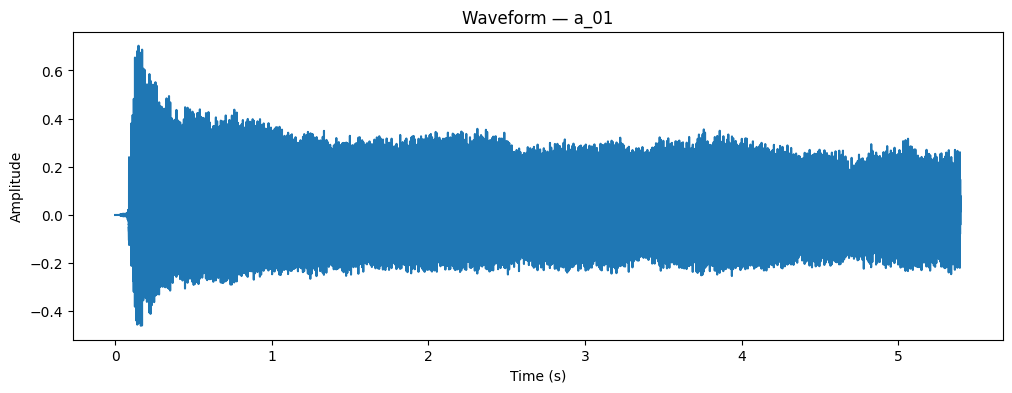

In [48]:
audio_path = (
  wav_dir / "a_01.wav"
)

wave, sr = inspect_audio(
  audio_path
)

## 4. Dataset Quality Check

All recordings are checked for basic technical consistency.

The measurements include:

- duration,
- peak amplitude,
- RMS,
- clipping count.

This is a technical quality-control step rather than an acoustic model of vowel identity.

In [49]:
qc_rows = []


for audio_path in wav_files:
  wave_temp, sr_temp = sf.read(
    audio_path
  )


  duration = (
    len(wave_temp)
    / sr_temp
  )


  peak_amp = np.max(
    np.abs(wave_temp)
  )


  rms = np.sqrt(
    np.mean(
      wave_temp ** 2
    )
  )


  clip_count = np.sum(
    np.abs(wave_temp) >= 0.999
  )


  qc_rows.append({
    "file": audio_path.name,
    "duration_s": duration,
    "peak_amp": peak_amp,
    "rms": rms,
    "clip_count": clip_count,
  })


qc_df = pd.DataFrame(
  qc_rows
)


qc_df = qc_df.round({
  "duration_s": 2,
  "peak_amp": 4,
  "rms": 4,
})


display(
  qc_df
)

,file,duration_s,peak_amp,rms,clip_count
0,a_01.wav,5.40,0.7024,0.0912,0
1,a_02.wav,6.25,0.4359,0.0776,0
2,e_01.wav,6.23,0.3087,0.0673,0
3,e_02.wav,5.44,0.2625,0.0560,0
4,i_01.wav,5.40,0.1791,0.0659,0
5,i_02.wav,6.08,0.1623,0.0532,0
6,o_01.wav,6.17,0.2318,0.0579,0
7,o_02.wav,5.50,0.1819,0.0476,0
8,u_01.wav,6.57,0.2397,0.0675,0
9,u_02.wav,6.21,0.1647,0.0480,0


## 5. Fundamental-Frequency Check

The recordings should have reasonably similar fundamental frequencies because vowel spectra are sampled by harmonics whose spacing depends on f0.

A simple autocorrelation-based estimator is used to check pitch consistency.

This f0 estimator is used for quality control rather than as the central DeVowel algorithm.

In [50]:
def estimate_frame_f0(
  frame,
  sr,
  fmin=70,
  fmax=500,
):
  frame = (
    frame
    - np.mean(frame)
  )


  frame = (
    frame
    * np.hanning(
      len(frame)
    )
  )


  autocorr = correlate(
    frame,
    frame,
    mode="full",
    method="fft",
  )


  autocorr = autocorr[
    len(autocorr) // 2:
  ]


  min_lag = int(
    sr / fmax
  )

  max_lag = int(
    sr / fmin
  )


  search = autocorr[
    min_lag:
    max_lag + 1
  ]


  peak_lag = (
    np.argmax(search)
    + min_lag
  )


  return (
    sr / peak_lag
  )

In [51]:
def estimate_audio_f0(
  wave,
  sr,
  center_duration=2.0,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  frame_length = int(
    0.05 * sr
  )

  hop_length = int(
    0.02 * sr
  )


  f0_values = []


  for start_idx in range(
    0,
    len(stable_wave)
    - frame_length,
    hop_length,
  ):
    frame = stable_wave[
      start_idx:
      start_idx + frame_length
    ]


    frame_rms = np.sqrt(
      np.mean(
        frame ** 2
      )
    )


    if frame_rms < 0.01:
      continue


    f0 = estimate_frame_f0(
      frame,
      sr,
    )


    f0_values.append(
      f0
    )


  return np.array(
    f0_values
  )

In [52]:
def estimate_audio_f0(
  wave,
  sr,
  center_duration=2.0,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  frame_length = int(
    0.05 * sr
  )

  hop_length = int(
    0.02 * sr
  )


  f0_values = []


  for start_idx in range(
    0,
    len(stable_wave)
    - frame_length,
    hop_length,
  ):
    frame = stable_wave[
      start_idx:
      start_idx + frame_length
    ]


    frame_rms = np.sqrt(
      np.mean(
        frame ** 2
      )
    )


    if frame_rms < 0.01:
      continue


    f0 = estimate_frame_f0(
      frame,
      sr,
    )


    f0_values.append(
      f0
    )


  return np.array(
    f0_values
  )

## 6. Spectrum Analysis

For each recording, the stable central 2 seconds are analyzed.

Pipeline:

1. select the central segment,
2. remove DC offset,
3. apply a Hann window,
4. compute the real FFT,
5. calculate magnitude,
6. create the frequency axis,
7. convert magnitude to dB,
8. normalize the maximum to 0 dB.

The narrow peaks of the raw spectrum mainly correspond to source harmonics.

The broader shape across harmonics is related to vocal-tract filtering.

In [53]:
def compute_spectrum(
  wave,
  sr,
  center_duration=2.0,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  stable_wave = (
    stable_wave
    - np.mean(stable_wave)
  )


  window = np.hanning(
    len(stable_wave)
  )


  windowed_wave = (
    stable_wave
    * window
  )


  spectrum = np.fft.rfft(
    windowed_wave
  )


  mag = np.abs(
    spectrum
  )


  freqs = np.fft.rfftfreq(
    len(windowed_wave),
    d=1 / sr,
  )


  mag_db = (
    20
    * np.log10(
      mag + 1e-12
    )
  )


  mag_db = (
    mag_db
    - np.max(mag_db)
  )


  return (
    freqs,
    mag_db,
  )

In [54]:
audio_path = (
  wav_dir / "a_01.wav"
)

wave, sr = sf.read(
  audio_path
)


freqs, mag_db = compute_spectrum(
  wave,
  sr,
)


print(
  "Sample rate:",
  sr,
)

print(
  "Frequency bins:",
  len(freqs),
)

print(
  "Spectrum bins:",
  len(mag_db),
)

print(
  "First frequencies:",
  freqs[:5],
)

print(
  "Last frequency:",
  freqs[-1],
)

print(
  "Bin spacing:",
  freqs[1] - freqs[0],
  "Hz",
)

print(
  "Maximum magnitude:",
  np.max(mag_db),
)

Sample rate: 44100
Frequency bins: 44101
Spectrum bins: 44101
First frequencies: [0.  0.5 1.  1.5 2. ]
Last frequency: 22050.0
Bin spacing: 0.5 Hz
Maximum magnitude: 0.0


### 6.1 Raw Spectrum

The raw FFT spectrum contains many narrow harmonic peaks.

These individual peaks should not be interpreted directly as formants.

Formants are broader vocal-tract resonances that shape the relative amplitudes of multiple harmonics.

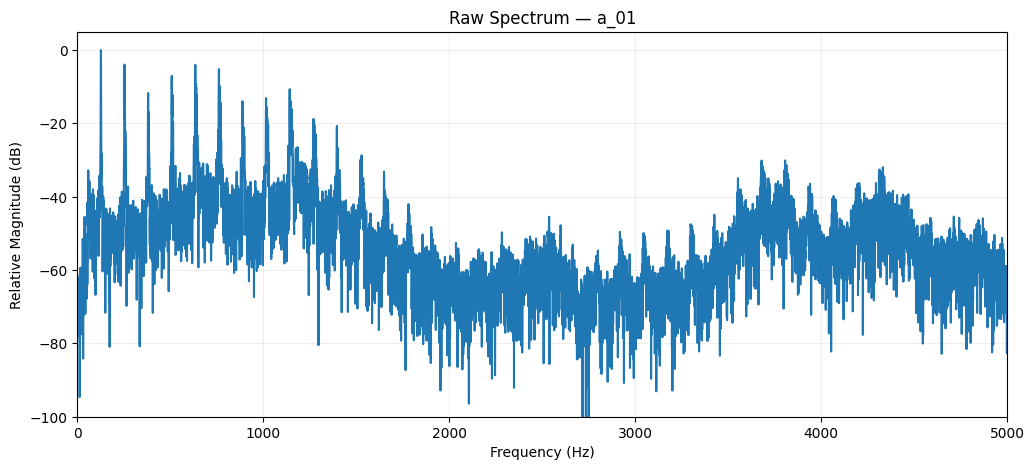

In [55]:
mask = (
  freqs <= 5000
)


plt.figure(
  figsize=(12, 5)
)


plt.plot(
  freqs[mask],
  mag_db[mask],
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Raw Spectrum — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -100,
  5,
)

plt.grid(
  alpha=0.2
)


plt.show()

## 7. Gaussian-Smoothed Spectral Envelope

The raw spectrum is dominated by narrow harmonic peaks.

Gaussian smoothing is used as a first exploratory approximation of the broader spectral envelope.

The smoothing parameter is specified in Hz but `gaussian_filter1d()` operates in array-bin units.

Therefore:

smoothing width in Hz
→ divide by FFT-bin spacing
→ smoothing sigma in bins

After smoothing, the envelope is normalized again so that its maximum is 0 dB.

This curve is an exploratory spectral-envelope estimate, not a formal formant measurement.

In [56]:
def compute_spectral_envelope(
  freqs,
  mag_db,
  smoothing_sigma_hz=50,
):
  bin_spacing_hz = (
    freqs[1]
    - freqs[0]
  )


  sigma_bins = (
    smoothing_sigma_hz
    / bin_spacing_hz
  )


  envelope_db = gaussian_filter1d(
    mag_db,
    sigma=sigma_bins,
  )


  envelope_db = (
    envelope_db
    - np.max(envelope_db)
  )


  return envelope_db

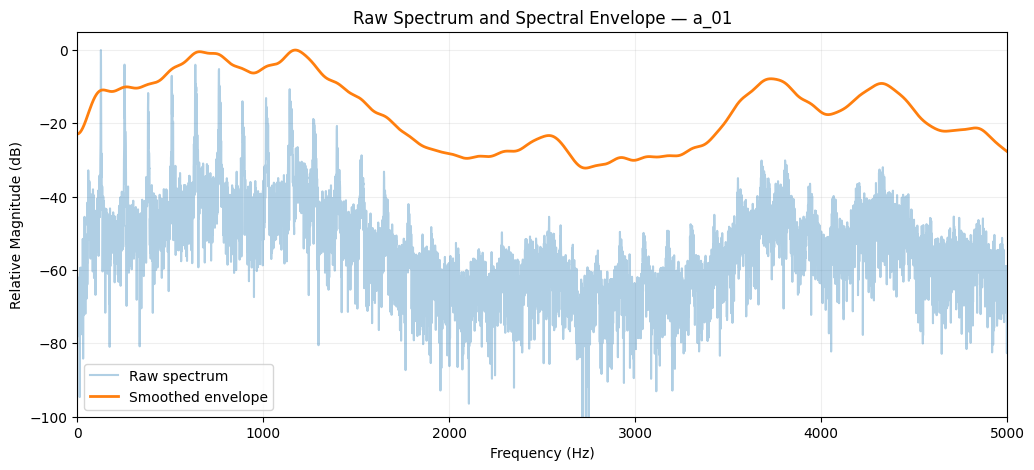

In [57]:
envelope_db = compute_spectral_envelope(
  freqs,
  mag_db,
  smoothing_sigma_hz=50,
)


mask = (
  freqs <= 5000
)


plt.figure(
  figsize=(12, 5)
)


plt.plot(
  freqs[mask],
  mag_db[mask],
  alpha=0.35,
  label="Raw spectrum",
)


plt.plot(
  freqs[mask],
  envelope_db[mask],
  linewidth=2,
  label="Smoothed envelope",
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Raw Spectrum and Spectral Envelope — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -100,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

## 8. Vowel Spectral-Envelope Comparison

One take from each vowel is compared.

Each envelope is normalized independently.

The purpose is therefore to compare broad spectral shape rather than absolute recording loudness.

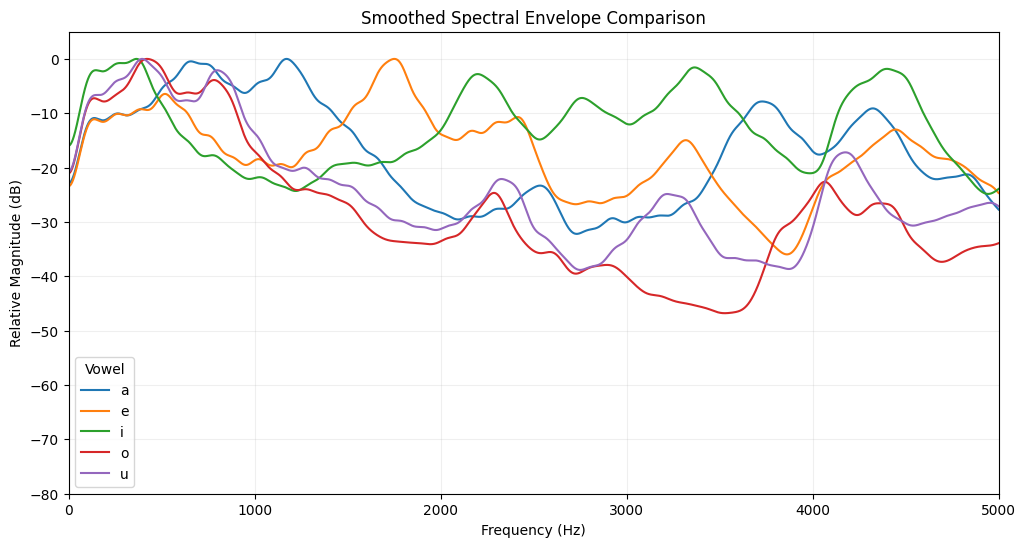

In [58]:
vowels = [
  "a",
  "e",
  "i",
  "o",
  "u",
]


comparison_files = [
  "a_01.wav",
  "e_01.wav",
  "i_01.wav",
  "o_01.wav",
  "u_01.wav",
]


plt.figure(
  figsize=(12, 6)
)


for filename in comparison_files:
  audio_path = (
    wav_dir / filename
  )


  wave_temp, sr_temp = sf.read(
    audio_path
  )


  freqs_temp, mag_db_temp = compute_spectrum(
    wave_temp,
    sr_temp,
  )


  envelope_temp = compute_spectral_envelope(
    freqs_temp,
    mag_db_temp,
    smoothing_sigma_hz=50,
  )


  mask = (
    freqs_temp <= 5000
  )


  plt.plot(
    freqs_temp[mask],
    envelope_temp[mask],
    label=filename[0],
  )


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Smoothed Spectral Envelope Comparison"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -80,
  5,
)

plt.legend(
  title="Vowel"
)

plt.grid(
  alpha=0.2
)


plt.show()

## 9. Within-Vowel Repeatability

Each vowel was recorded twice.

The two takes of each vowel are compared to determine whether the broad spectral-envelope structure is repeatable.

Stable similarity within vowels is necessary before interpreting differences between vowels as vowel-dependent structure.

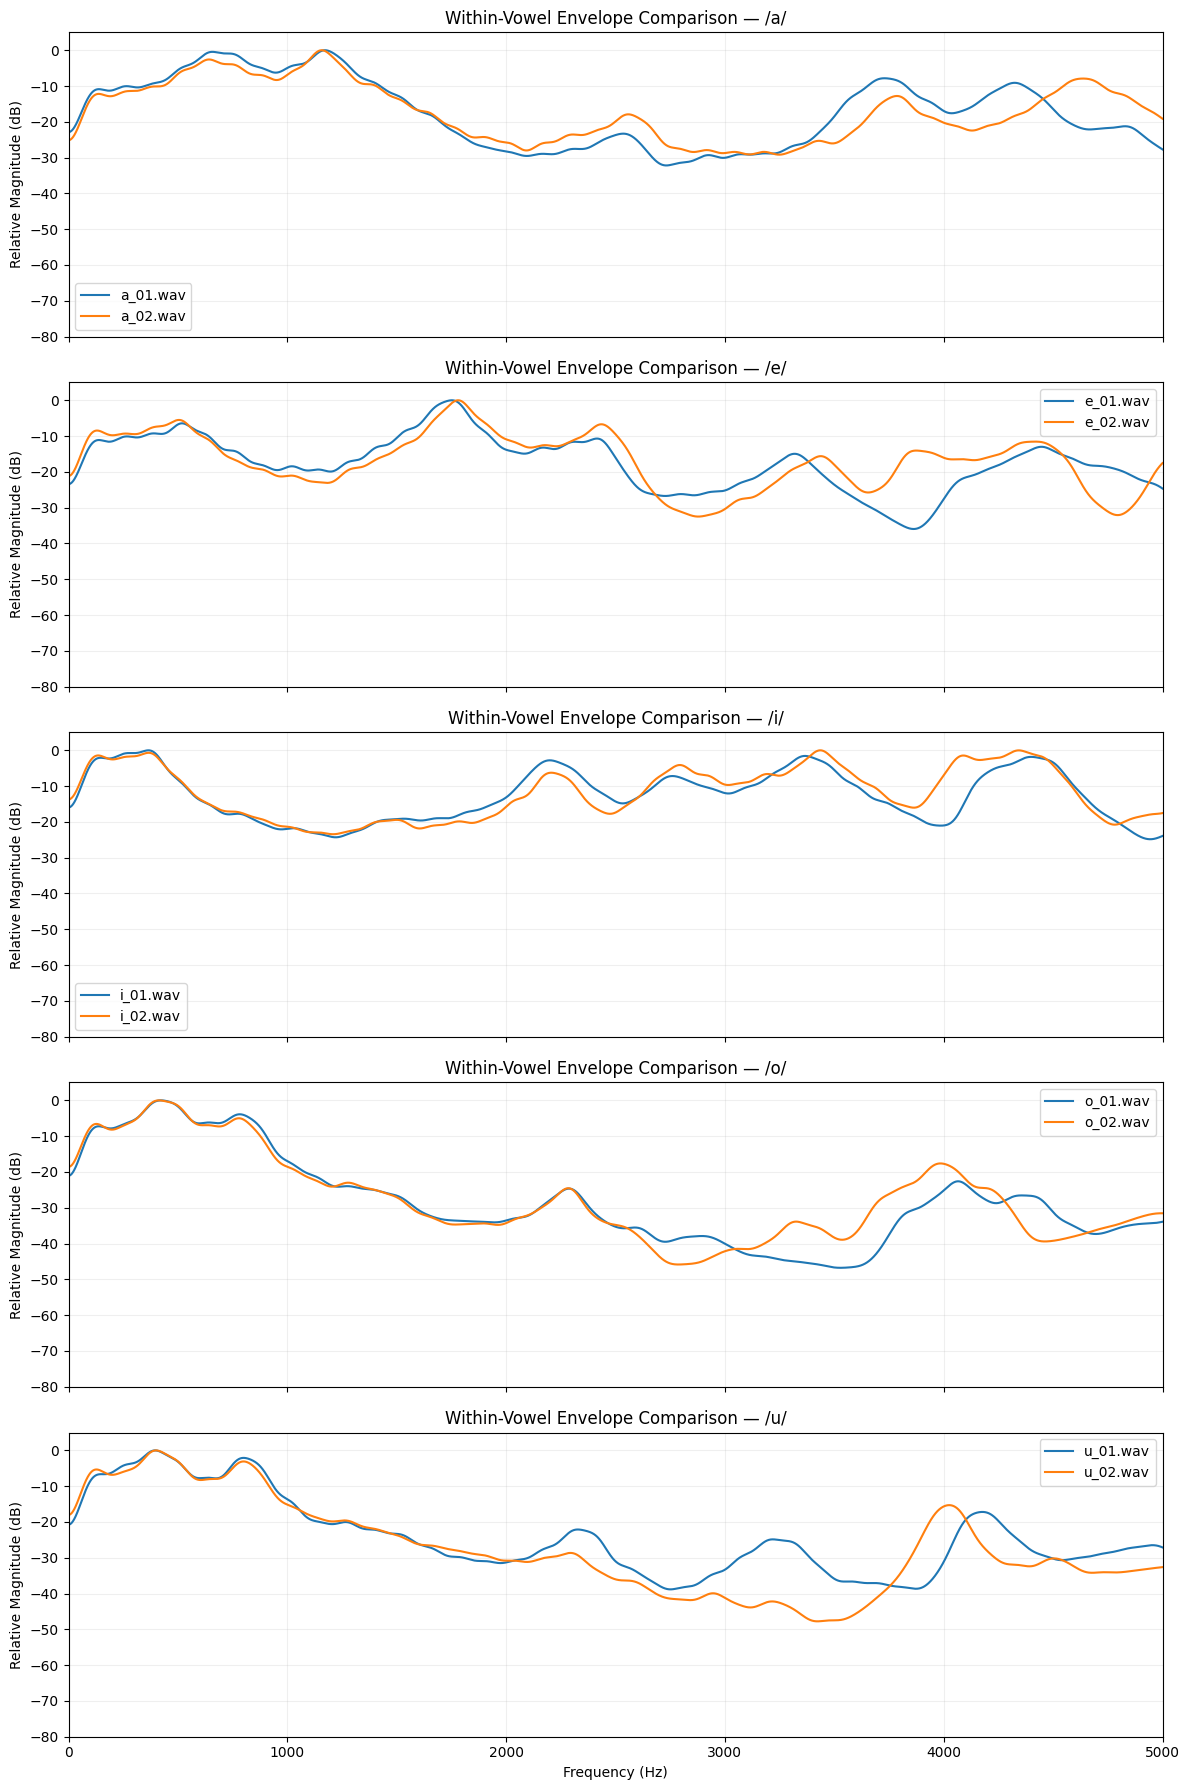

In [59]:
fig, axes = plt.subplots(
  len(vowels),
  1,
  figsize=(12, 18),
  sharex=True,
  sharey=True,
)


for ax, vowel in zip(
  axes,
  vowels,
):
  filenames = [
    f"{vowel}_01.wav",
    f"{vowel}_02.wav",
  ]


  for filename in filenames:
    audio_path = (
      wav_dir / filename
    )


    wave_temp, sr_temp = sf.read(
      audio_path
    )


    freqs_temp, mag_db_temp = compute_spectrum(
      wave_temp,
      sr_temp,
    )


    envelope_temp = compute_spectral_envelope(
      freqs_temp,
      mag_db_temp,
      smoothing_sigma_hz=50,
    )


    mask = (
      freqs_temp <= 5000
    )


    ax.plot(
      freqs_temp[mask],
      envelope_temp[mask],
      label=filename,
    )


  ax.set_title(
    f"Within-Vowel Envelope Comparison — /{vowel}/"
  )

  ax.set_ylabel(
    "Relative Magnitude (dB)"
  )

  ax.set_ylim(
    -80,
    5,
  )

  ax.grid(
    alpha=0.2
  )

  ax.legend()


axes[-1].set_xlabel(
  "Frequency (Hz)"
)

axes[-1].set_xlim(
  0,
  5000,
)


plt.tight_layout()

plt.show()

In [60]:
envelopes = {}

reference_freqs = None


for audio_path in wav_files:
  wave_temp, sr_temp = sf.read(
    audio_path
  )


  freqs_temp, mag_db_temp = compute_spectrum(
    wave_temp,
    sr_temp,
  )


  envelope_temp = compute_spectral_envelope(
    freqs_temp,
    mag_db_temp,
    smoothing_sigma_hz=50,
  )


  if reference_freqs is None:
    reference_freqs = (
      freqs_temp
    )


  if not np.allclose(
    freqs_temp,
    reference_freqs,
  ):
    raise ValueError(
      "Frequency axes are not identical."
    )


  envelopes[
    audio_path.name
  ] = envelope_temp


print(
  "Stored envelopes:",
  len(envelopes),
)

Stored envelopes: 10


### 9.1 Numerical Envelope Similarity

Two exploratory similarity measurements are used:

- Pearson correlation: similarity of overall curve shape.
- MAE (Mean Absolute Error): average absolute difference in dB.

Higher correlation and lower MAE indicate greater similarity.

These are exploratory descriptors rather than definitive perceptual-distance measures.

In [61]:
analysis_mask = (
  (reference_freqs >= 100)
  & (reference_freqs <= 5000)
)


repeatability_rows = []


for vowel in vowels:
  file_01 = (
    f"{vowel}_01.wav"
  )

  file_02 = (
    f"{vowel}_02.wav"
  )


  envelope_01 = envelopes[
    file_01
  ][analysis_mask]


  envelope_02 = envelopes[
    file_02
  ][analysis_mask]


  corr = np.corrcoef(
    envelope_01,
    envelope_02,
  )[0, 1]


  mae_db = np.mean(
    np.abs(
      envelope_01
      - envelope_02
    )
  )


  repeatability_rows.append({
    "vowel": vowel,
    "correlation": corr,
    "mae_db": mae_db,
  })


repeatability_df = pd.DataFrame(
  repeatability_rows
)


repeatability_df = repeatability_df.round({
  "correlation": 3,
  "mae_db": 2,
})


display(
  repeatability_df
)

,vowel,correlation,mae_db
0,a,0.850,3.77
1,e,0.709,4.21
2,i,0.874,2.45
3,o,0.923,3.19
4,u,0.870,4.84


### 9.2 Within-Vowel vs Between-Vowel Differences

All recording pairs are classified as:

- `within`: two takes of the same vowel,
- `between`: recordings of different vowels.

If within-vowel pairs are systematically more similar than between-vowel pairs, the envelope representation contains stable vowel-dependent information.

In [62]:
pair_rows = []


filenames = sorted(
  envelopes.keys()
)


for i in range(
  len(filenames)
):
  for j in range(
    i + 1,
    len(filenames)
  ):
    file_a = filenames[i]
    file_b = filenames[j]


    vowel_a = file_a[0]
    vowel_b = file_b[0]


    envelope_a = envelopes[
      file_a
    ][analysis_mask]


    envelope_b = envelopes[
      file_b
    ][analysis_mask]


    corr = np.corrcoef(
      envelope_a,
      envelope_b,
    )[0, 1]


    mae_db = np.mean(
      np.abs(
        envelope_a
        - envelope_b
      )
    )


    pair_type = (
      "within"
      if vowel_a == vowel_b
      else "between"
    )


    pair_rows.append({
      "file_a": file_a,
      "file_b": file_b,
      "type": pair_type,
      "correlation": corr,
      "mae_db": mae_db,
    })


pair_df = pd.DataFrame(
  pair_rows
)


display(
  pair_df.head(10)
)

,file_a,file_b,type,correlation,mae_db
0,a_01.wav,a_02.wav,within,0.850146,3.767493
1,a_01.wav,e_01.wav,between,0.084364,9.380590
2,a_01.wav,e_02.wav,between,0.198429,8.567429
3,a_01.wav,i_01.wav,between,-0.282875,12.213067
4,a_01.wav,i_02.wav,between,-0.199843,12.319853
5,a_01.wav,o_01.wav,between,0.684143,12.141327
6,a_01.wav,o_02.wav,between,0.739219,11.434546
7,a_01.wav,u_01.wav,between,0.617099,8.807440
8,a_01.wav,u_02.wav,between,0.693331,11.220980
9,a_02.wav,e_01.wav,between,0.184433,8.110316


In [63]:
summary_df = (
  pair_df
  .groupby("type")[
    [
      "correlation",
      "mae_db",
    ]
  ]
  .mean()
  .round(3)
)


display(
  summary_df
)

,correlation,mae_db
type,,
between,0.288,11.625
within,0.845,3.693


## 10. Spectral-Envelope Peak Detection

Local maxima of the Gaussian-smoothed spectral envelope are detected as exploratory resonance candidates.

These peaks are not automatically identified as F1, F2, or F3.

`find_peaks()` detects mathematical local maxima according to the supplied conditions; it does not know what a formant is.

A prominence threshold is used to reject very small local fluctuations.

In [64]:
audio_path = (
  wav_dir / "a_01.wav"
)


wave, sr = sf.read(
  audio_path
)


freqs, mag_db = compute_spectrum(
  wave,
  sr,
)


envelope_db = compute_spectral_envelope(
  freqs,
  mag_db,
  smoothing_sigma_hz=50,
)


peak_mask = (
  (freqs >= 100)
  & (freqs <= 5000)
)


analysis_freqs = freqs[
  peak_mask
]

analysis_envelope = envelope_db[
  peak_mask
]


peak_indices, properties = find_peaks(
  analysis_envelope,
  prominence=3,
)


peak_freqs = analysis_freqs[
  peak_indices
]

peak_db = analysis_envelope[
  peak_indices
]


print(
  "Detected peak frequencies:"
)

print(
  np.round(
    peak_freqs,
    1,
  )
)

Detected peak frequencies:
[ 657.5 1172.  2535.5 3729.  4324. ]


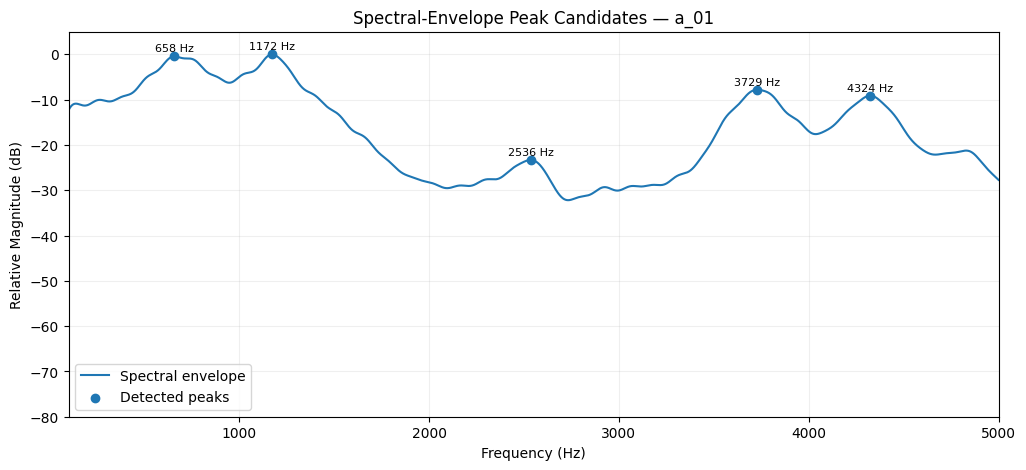

In [65]:
plt.figure(
  figsize=(12, 5)
)


plt.plot(
  analysis_freqs,
  analysis_envelope,
  label="Spectral envelope",
)


plt.scatter(
  peak_freqs,
  peak_db,
  zorder=3,
  label="Detected peaks",
)


for freq, db in zip(
  peak_freqs,
  peak_db,
):
  plt.text(
    freq,
    db + 1,
    f"{freq:.0f} Hz",
    ha="center",
    fontsize=8,
  )


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Spectral-Envelope Peak Candidates — a_01"
)

plt.xlim(
  100,
  5000,
)

plt.ylim(
  -80,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

In [66]:
peak_rows = []


for vowel in vowels:
  filename = (
    f"{vowel}_01.wav"
  )


  audio_path = (
    wav_dir / filename
  )


  wave_temp, sr_temp = sf.read(
    audio_path
  )


  freqs_temp, mag_db_temp = compute_spectrum(
    wave_temp,
    sr_temp,
  )


  envelope_temp = compute_spectral_envelope(
    freqs_temp,
    mag_db_temp,
    smoothing_sigma_hz=50,
  )


  mask = (
    (freqs_temp >= 100)
    & (freqs_temp <= 5000)
  )


  freqs_roi = freqs_temp[
    mask
  ]

  envelope_roi = envelope_temp[
    mask
  ]


  peak_indices, properties = find_peaks(
    envelope_roi,
    prominence=3,
  )


  peak_freqs_temp = freqs_roi[
    peak_indices
  ]


  peak_rows.append({
    "vowel": vowel,
    "peak_freqs_hz": np.round(
      peak_freqs_temp,
      1,
    ),
  })


peak_df = pd.DataFrame(
  peak_rows
)


display(
  peak_df
)

,vowel,peak_freqs_hz
0,a,"[657.5, 1172.0, 2535.5, 3729.0, 4324.0]"
1,e,"[518.5, 1752.0, 2415.0, 3318.5, 4446.5]"
2,i,"[365.0, 2199.5, 2760.0, 3366.0, 4399.5]"
3,o,"[422.0, 2287.5, 4066.0]"
4,u,"[395.5, 800.0, 2327.5, 3219.0, 4177.0]"


## 11. LPC Spectral Envelope

Gaussian smoothing is useful for visualization, but it does not explicitly model vocal-tract resonances.

Linear Predictive Coding (LPC) models a speech sample as approximately predictable from previous samples.

The resulting prediction model can be interpreted as an all-pole filter.

The resonances of this filter provide an approximation of vocal-tract resonance structure.

LPC is still a model rather than a direct physical measurement of the vocal tract.

In [67]:
def compute_lpc_envelope(
  wave,
  sr,
  center_duration=2.0,
  target_sr=10000,
  order=16,
  n_freqs=4096,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  stable_wave = (
    stable_wave
    - np.mean(stable_wave)
  )


  if sr != target_sr:
    gcd = np.gcd(
      sr,
      target_sr,
    )


    up = (
      target_sr // gcd
    )

    down = (
      sr // gcd
    )


    stable_wave = resample_poly(
      stable_wave,
      up,
      down,
    )


    analysis_sr = (
      target_sr
    )

  else:
    analysis_sr = (
      sr
    )


  window = np.hanning(
    len(stable_wave)
  )


  windowed_wave = (
    stable_wave
    * window
  )


  lpc_coeffs = librosa.lpc(
    windowed_wave,
    order=order,
  )


  freqs_lpc, response = freqz(
    b=[1.0],
    a=lpc_coeffs,
    worN=n_freqs,
    fs=analysis_sr,
  )


  envelope_lpc_db = (
    20
    * np.log10(
      np.abs(response)
      + 1e-12
    )
  )


  envelope_lpc_db = (
    envelope_lpc_db
    - np.max(
      envelope_lpc_db
    )
  )


  return (
    freqs_lpc,
    envelope_lpc_db,
    lpc_coeffs,
  )

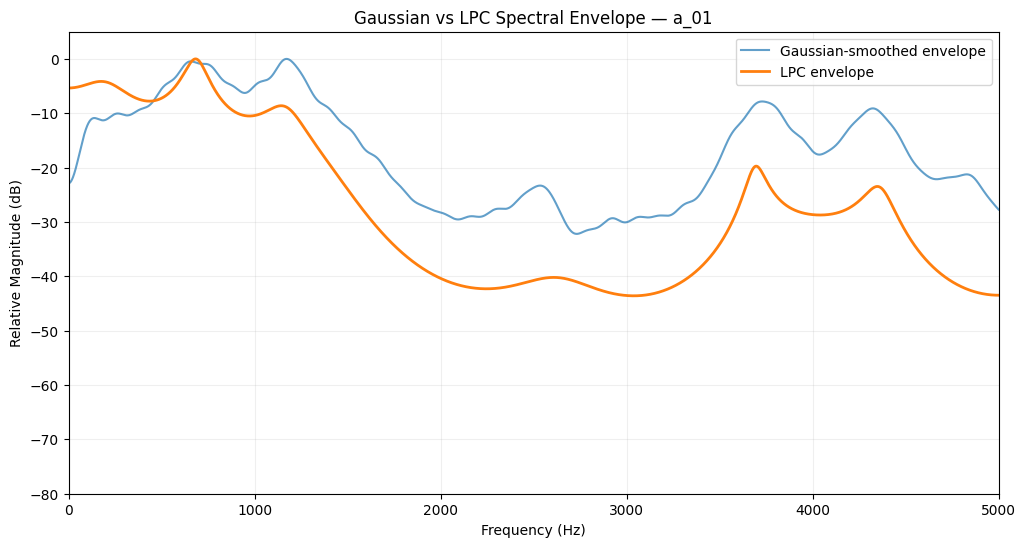

In [68]:
audio_path = (
  wav_dir / "a_01.wav"
)

wave, sr = sf.read(
  audio_path
)


freqs_raw, mag_db = compute_spectrum(
  wave,
  sr,
)


gaussian_envelope = compute_spectral_envelope(
  freqs_raw,
  mag_db,
  smoothing_sigma_hz=50,
)


(
  freqs_lpc,
  lpc_envelope,
  lpc_coeffs,
) = compute_lpc_envelope(
  wave,
  sr,
  order=16,
)


raw_mask = (
  freqs_raw <= 5000
)


plt.figure(
  figsize=(12, 6)
)


plt.plot(
  freqs_raw[raw_mask],
  gaussian_envelope[raw_mask],
  label="Gaussian-smoothed envelope",
  alpha=0.7,
)


plt.plot(
  freqs_lpc,
  lpc_envelope,
  label="LPC envelope",
  linewidth=2,
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Gaussian vs LPC Spectral Envelope — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -80,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

### 11.1 LPC Order Stability

The LPC spectral envelope depends on model order.

Too low an order may miss resonances.

Too high an order may model small spectral details as additional resonances.

Several orders are therefore compared.

Resonances that remain at approximately the same frequency across reasonable orders are more robust candidates.

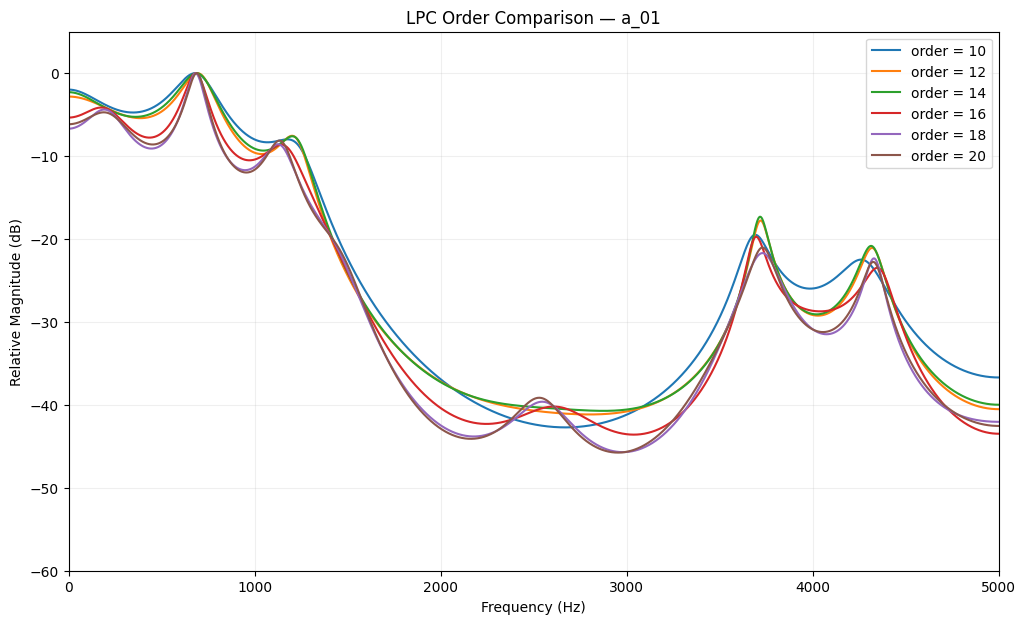

In [69]:
lpc_orders = [
  10,
  12,
  14,
  16,
  18,
  20,
]


plt.figure(
  figsize=(12, 7)
)


for order in lpc_orders:
  (
    freqs_lpc,
    lpc_envelope,
    lpc_coeffs,
  ) = compute_lpc_envelope(
    wave,
    sr,
    order=order,
  )


  plt.plot(
    freqs_lpc,
    lpc_envelope,
    label=f"order = {order}",
  )


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "LPC Order Comparison — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -60,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

## 12. LPC Poles and Formant Candidates

The LPC spectral envelope is the frequency response of an all-pole model.

Instead of detecting peaks only from the plotted curve, the roots of the LPC prediction polynomial can be analyzed directly.

Complex-conjugate pole pairs correspond to resonant modes.

For each pole:

- pole angle determines resonance frequency,
- pole radius determines damping,
- damping can be expressed as bandwidth.

This produces resonance candidates represented by both frequency and bandwidth.

These candidates are not automatically guaranteed to be physical formants.

In [70]:
def compute_lpc_formant_candidates(
  frame,
  sr,
  order=12,
  pre_emphasis=0.97,
  min_freq=90,
  max_freq=5000,
  max_bandwidth=500,
):
  frame = (
    frame
    - np.mean(frame)
  )


  emphasized = lfilter(
    [1.0, -pre_emphasis],
    [1.0],
    frame,
  )


  window = np.hamming(
    len(emphasized)
  )


  windowed = (
    emphasized
    * window
  )


  lpc_coeffs = librosa.lpc(
    windowed,
    order=order,
  )


  roots = np.roots(
    lpc_coeffs
  )


  roots = roots[
    np.imag(roots) >= 0
  ]


  radii = np.abs(
    roots
  )


  angles = np.angle(
    roots
  )


  formant_freqs = (
    angles
    * sr
    / (2 * np.pi)
  )


  bandwidths = (
    -sr
    / np.pi
    * np.log(
      radii
    )
  )


  valid = (
    (formant_freqs >= min_freq)
    & (formant_freqs <= max_freq)
    & (radii < 1.0)
    & (bandwidths > 0)
    & (bandwidths <= max_bandwidth)
  )


  formant_freqs = (
    formant_freqs[
      valid
    ]
  )


  bandwidths = (
    bandwidths[
      valid
    ]
  )


  order_idx = np.argsort(
    formant_freqs
  )


  formant_freqs = (
    formant_freqs[
      order_idx
    ]
  )


  bandwidths = (
    bandwidths[
      order_idx
    ]
  )


  return (
    formant_freqs,
    bandwidths,
  )

In [71]:
audio_path = (
  wav_dir / "a_01.wav"
)


wave, sr = sf.read(
  audio_path
)


target_sr = 10000


center_sample = (
  len(wave) // 2
)


frame_duration = (
  0.03
)


half_frame = int(
  frame_duration
  * sr
  / 2
)


frame = wave[
  center_sample - half_frame:
  center_sample + half_frame
]


gcd = np.gcd(
  sr,
  target_sr,
)


up = (
  target_sr // gcd
)

down = (
  sr // gcd
)


frame_resampled = resample_poly(
  frame,
  up,
  down,
)


(
  formant_freqs,
  formant_bandwidths,
) = compute_lpc_formant_candidates(
  frame_resampled,
  target_sr,
  order=12,
)


formant_candidate_df = pd.DataFrame({
  "frequency_hz": formant_freqs,
  "bandwidth_hz": formant_bandwidths,
})


formant_candidate_df = (
  formant_candidate_df
  .round(1)
)


display(
  formant_candidate_df
)

,frequency_hz,bandwidth_hz
0,692.3,135.3
1,1209.3,122.5
2,3698.4,135.7
3,4369.5,139.9


## 13. Temporal LPC Resonance Stability

A single 30 ms frame provides only a snapshot of the vocal-tract model.

A sustained vowel should produce resonance candidates that remain in similar frequency regions across many neighboring frames.

The central 2 seconds of each recording are therefore divided into short overlapping frames.

For each frame:

1. LPC coefficients are estimated,
2. LPC polynomial roots are calculated,
3. pole frequencies and bandwidths are extracted,
4. implausibly broad resonances are removed.

The resulting frequency-bandwidth candidates are observed across time.

Stable horizontal clusters of candidates are stronger formant candidates than isolated or rapidly moving poles.

In [72]:
def track_lpc_candidates(
  wave,
  sr,
  center_duration=2.0,
  target_sr=10000,
  frame_duration=0.03,
  hop_duration=0.01,
  order=12,
  pre_emphasis=0.97,
  min_freq=90,
  max_freq=5000,
  max_bandwidth=500,
):
  center_sample = (
    len(wave) // 2
  )

  half_length = int(
    center_duration
    * sr
    / 2
  )

  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )

  stable_wave = wave[
    start:end
  ]


  if sr != target_sr:
    gcd = np.gcd(
      sr,
      target_sr,
    )

    up = (
      target_sr // gcd
    )

    down = (
      sr // gcd
    )

    stable_wave = resample_poly(
      stable_wave,
      up,
      down,
    )

    analysis_sr = target_sr

  else:
    analysis_sr = sr


  frame_length = int(
    frame_duration
    * analysis_sr
  )

  hop_length = int(
    hop_duration
    * analysis_sr
  )


  candidate_rows = []


  for start_idx in range(
    0,
    len(stable_wave)
    - frame_length
    + 1,
    hop_length,
  ):
    frame = stable_wave[
      start_idx:
      start_idx + frame_length
    ]


    frame_rms = np.sqrt(
      np.mean(
        frame ** 2
      )
    )


    if frame_rms < 0.01:
      continue


    (
      formant_freqs,
      bandwidths,
    ) = compute_lpc_formant_candidates(
      frame,
      analysis_sr,
      order=order,
      pre_emphasis=pre_emphasis,
      min_freq=min_freq,
      max_freq=max_freq,
      max_bandwidth=max_bandwidth,
    )


    frame_center_s = (
      start_idx
      + frame_length / 2
    ) / analysis_sr


    for freq, bandwidth in zip(
      formant_freqs,
      bandwidths,
    ):
      candidate_rows.append({
        "time_s": frame_center_s,
        "frequency_hz": freq,
        "bandwidth_hz": bandwidth,
      })


  return pd.DataFrame(
    candidate_rows
  )

In [73]:
audio_path = (
  wav_dir / "a_01.wav"
)

wave, sr = sf.read(
  audio_path
)


a_candidates_df = track_lpc_candidates(
  wave,
  sr,
  center_duration=2.0,
  target_sr=10000,
  frame_duration=0.03,
  hop_duration=0.01,
  order=12,
  max_bandwidth=500,
)


print(
  "Detected candidates:",
  len(a_candidates_df),
)

print(
  "Analyzed frames approximately:",
  a_candidates_df["time_s"].nunique(),
)


display(
  a_candidates_df.head(10)
)

Detected candidates: 793
Analyzed frames approximately: 198


,time_s,frequency_hz,bandwidth_hz
0,0.015,669.425991,170.881553
1,0.015,1210.572245,233.513520
2,0.015,3772.310762,151.335041
3,0.015,4348.899525,210.436848
4,0.025,700.147517,145.652135
5,0.025,1194.469490,137.427795
6,0.025,3790.755527,197.882534
7,0.025,4352.398194,201.310360
8,0.035,708.472605,137.180645
9,0.035,1221.343799,121.256877


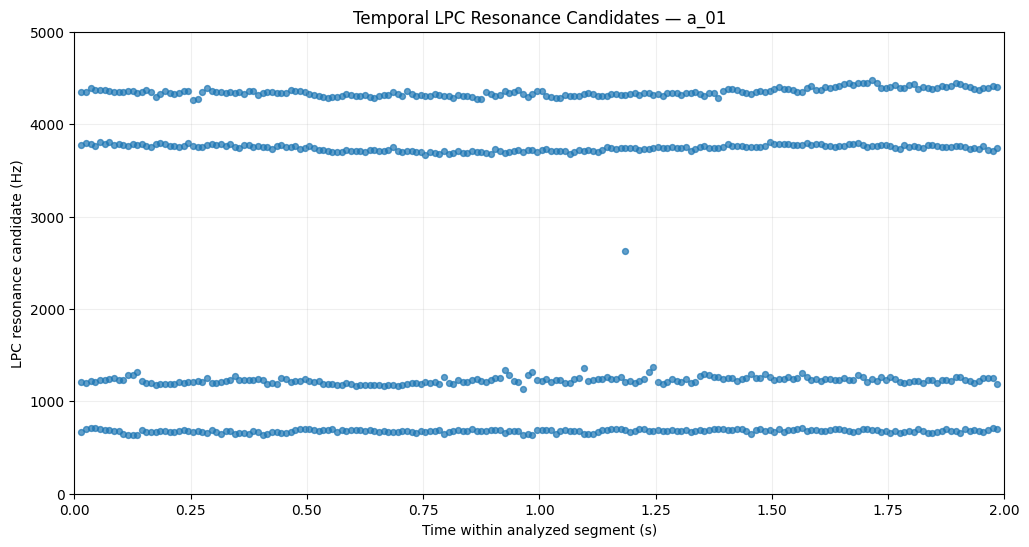

In [74]:
plt.figure(
  figsize=(12, 6)
)


plt.scatter(
  a_candidates_df["time_s"],
  a_candidates_df["frequency_hz"],
  s=18,
  alpha=0.7,
)


plt.xlabel(
  "Time within analyzed segment (s)"
)

plt.ylabel(
  "LPC resonance candidate (Hz)"
)

plt.title(
  "Temporal LPC Resonance Candidates — a_01"
)

plt.xlim(
  0,
  2.0,
)

plt.ylim(
  0,
  5000,
)

plt.grid(
  alpha=0.2
)


plt.show()

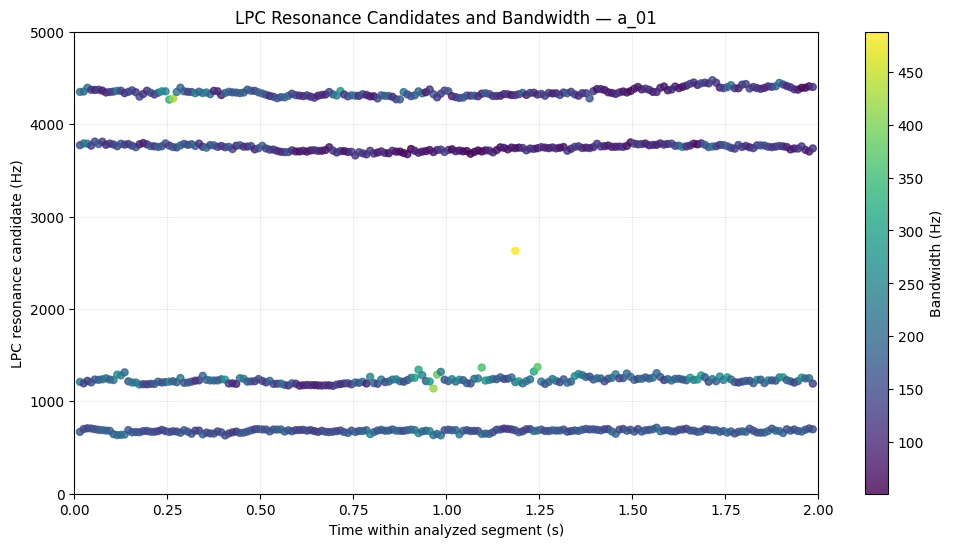

In [75]:
plt.figure(
  figsize=(12, 6)
)


scatter = plt.scatter(
  a_candidates_df["time_s"],
  a_candidates_df["frequency_hz"],
  c=a_candidates_df["bandwidth_hz"],
  s=25,
  alpha=0.8,
)


plt.colorbar(
  scatter,
  label="Bandwidth (Hz)",
)


plt.xlabel(
  "Time within analyzed segment (s)"
)

plt.ylabel(
  "LPC resonance candidate (Hz)"
)

plt.title(
  "LPC Resonance Candidates and Bandwidth — a_01"
)

plt.xlim(
  0,
  2.0,
)

plt.ylim(
  0,
  5000,
)

plt.grid(
  alpha=0.2
)


plt.show()

### 13.1 Resonance-Candidate Frequency Distribution

Stable vocal-tract resonances should produce LPC pole candidates repeatedly in similar frequency regions across frames.

A histogram of all candidate frequencies provides a simple view of these recurring regions.

Dense frequency regions are possible stable resonance bands.

The histogram is used for exploration and does not itself assign formal F1, F2, or F3 labels.

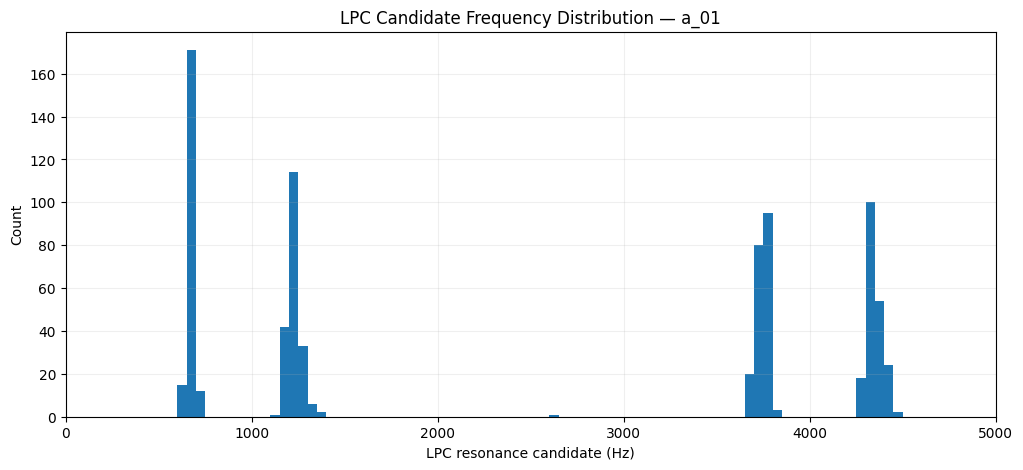

In [76]:
plt.figure(
  figsize=(12, 5)
)


plt.hist(
  a_candidates_df["frequency_hz"],
  bins=np.arange(
    0,
    5050,
    50,
  ),
)


plt.xlabel(
  "LPC resonance candidate (Hz)"
)

plt.ylabel(
  "Count"
)

plt.title(
  "LPC Candidate Frequency Distribution — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.grid(
  alpha=0.2
)


plt.show()

## 14. Stable Resonance Bands

The temporal LPC analysis shows that resonance candidates repeatedly cluster in several frequency regions.

Rather than assigning formant labels to individual frames, candidate frequencies are now summarized into stable resonance bands.

The procedure is:

1. collect LPC resonance candidates across all frames,
2. construct a frequency histogram,
3. smooth the histogram,
4. detect persistent frequency-density peaks,
5. summarize candidates near each detected band.

For each stable band, we measure:

- median resonance frequency,
- frequency variation,
- median bandwidth,
- approximate temporal coverage.

This provides a more robust representation than using a single frame.

In [77]:
def summarize_resonance_bands(
  candidates_df,
  freq_min=100,
  freq_max=5000,
  hist_bin_hz=25,
  smoothing_sigma_hz=50,
  min_peak_distance_hz=200,
  prominence=2,
  band_half_width_hz=125,
):
  bin_edges = np.arange(
    freq_min,
    freq_max + hist_bin_hz,
    hist_bin_hz,
  )


  counts, edges = np.histogram(
    candidates_df["frequency_hz"],
    bins=bin_edges,
  )


  bin_centers = (
    edges[:-1]
    + edges[1:]
  ) / 2


  sigma_bins = (
    smoothing_sigma_hz
    / hist_bin_hz
  )


  smoothed_counts = gaussian_filter1d(
    counts.astype(float),
    sigma=sigma_bins,
  )


  min_peak_distance_bins = int(
    min_peak_distance_hz
    / hist_bin_hz
  )


  peak_indices, properties = find_peaks(
    smoothed_counts,
    prominence=prominence,
    distance=min_peak_distance_bins,
  )


  total_frames = (
    candidates_df["time_s"]
    .nunique()
  )


  band_rows = []


  for peak_idx in peak_indices:
    peak_center = (
      bin_centers[peak_idx]
    )


    band_mask = (
      np.abs(
        candidates_df["frequency_hz"]
        - peak_center
      )
      <= band_half_width_hz
    )


    band_data = candidates_df[
      band_mask
    ]


    if len(band_data) == 0:
      continue


    frame_count = (
      band_data["time_s"]
      .nunique()
    )


    coverage = (
      frame_count
      / total_frames
    )


    band_rows.append({
      "peak_center_hz": peak_center,
      "median_freq_hz": np.median(
        band_data["frequency_hz"]
      ),
      "freq_std_hz": np.std(
        band_data["frequency_hz"]
      ),
      "median_bandwidth_hz": np.median(
        band_data["bandwidth_hz"]
      ),
      "frame_coverage": coverage,
      "candidate_count": len(
        band_data
      ),
    })


  bands_df = pd.DataFrame(
    band_rows
  )


  if len(bands_df) > 0:
    bands_df = (
      bands_df
      .sort_values(
        "median_freq_hz"
      )
      .reset_index(
        drop=True
      )
    )


  return (
    bands_df,
    bin_centers,
    smoothed_counts,
  )

In [78]:
(
  a_bands_df,
  hist_freqs,
  smoothed_counts,
) = summarize_resonance_bands(
  a_candidates_df
)


a_bands_df = a_bands_df.round({
  "peak_center_hz": 1,
  "median_freq_hz": 1,
  "freq_std_hz": 1,
  "median_bandwidth_hz": 1,
  "frame_coverage": 3,
})


display(
  a_bands_df
)

,peak_center_hz,median_freq_hz,freq_std_hz,median_bandwidth_hz,frame_coverage,candidate_count
0,687.5,680.9,16.5,162.3,1.000,198
1,1212.5,1224.6,31.8,183.1,0.985,195
2,3737.5,3749.7,31.8,112.3,1.000,198
3,4337.5,4342.4,41.0,126.4,0.995,197


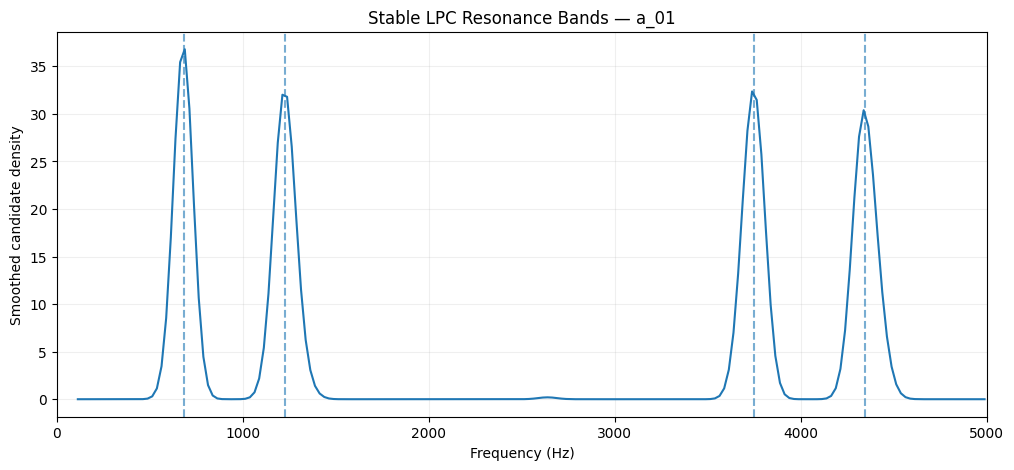

In [79]:
plt.figure(
  figsize=(12, 5)
)


plt.plot(
  hist_freqs,
  smoothed_counts,
)


for freq in a_bands_df[
  "median_freq_hz"
]:
  plt.axvline(
    freq,
    linestyle="--",
    alpha=0.6,
  )


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Smoothed candidate density"
)

plt.title(
  "Stable LPC Resonance Bands — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.grid(
  alpha=0.2
)


plt.show()

## 15. Stable Resonance Bands Across Vowels

The temporal LPC analysis is now applied to all five sustained vowels.

Each recording is analyzed using identical parameters.

Stable LPC resonance bands are summarized independently for each vowel.

The lowest stable resonance bands are then compared across vowels as potential F1 and F2 structures.

At this stage, the labels remain model-based formant estimates rather than direct physical measurements.

In [80]:
all_bands = {}


for vowel in vowels:
  filename = (
    f"{vowel}_01.wav"
  )


  audio_path = (
    wav_dir / filename
  )


  wave_temp, sr_temp = sf.read(
    audio_path
  )


  candidates_temp = track_lpc_candidates(
    wave_temp,
    sr_temp,
    center_duration=2.0,
    target_sr=10000,
    frame_duration=0.03,
    hop_duration=0.01,
    order=12,
    max_bandwidth=500,
  )


  (
    bands_temp,
    hist_freqs_temp,
    smoothed_counts_temp,
  ) = summarize_resonance_bands(
    candidates_temp
  )


  all_bands[
    vowel
  ] = bands_temp


  print()
  print(
    f"/{vowel}/"
  )

  display(
    bands_temp.round({
      "peak_center_hz": 1,
      "median_freq_hz": 1,
      "freq_std_hz": 1,
      "median_bandwidth_hz": 1,
      "frame_coverage": 3,
    })
  )


/a/


,peak_center_hz,median_freq_hz,freq_std_hz,median_bandwidth_hz,frame_coverage,candidate_count
0,687.5,680.9,16.5,162.3,1.000,198
1,1212.5,1224.6,31.8,183.1,0.985,195
2,3737.5,3749.7,31.8,112.3,1.000,198
3,4337.5,4342.4,41.0,126.4,0.995,197



/e/


,peak_center_hz,median_freq_hz,freq_std_hz,median_bandwidth_hz,frame_coverage,candidate_count
0,537.5,551.6,16.2,182.8,1.000,198
1,1712.5,1717.7,16.0,84.8,1.000,198
2,2287.5,2283.4,55.5,307.3,0.889,176
3,3337.5,3330.7,36.4,296.9,0.692,137
4,4437.5,4448.5,35.9,135.4,0.995,197



/i/


,peak_center_hz,median_freq_hz,freq_std_hz,median_bandwidth_hz,frame_coverage,candidate_count
0,337.5,328.4,7.2,88.0,1.000,198
1,2187.5,2180.1,31.5,187.8,0.975,193
2,3387.5,3399.7,29.8,145.1,1.000,198
3,4387.5,4390.1,21.3,75.7,1.000,198



/o/


,peak_center_hz,median_freq_hz,freq_std_hz,median_bandwidth_hz,frame_coverage,candidate_count
0,412.5,407.2,12.9,161.1,1.000,198
1,787.5,794.2,19.7,147.5,1.000,198
2,2362.5,2370.4,57.9,179.2,0.899,178
3,4037.5,4037.0,31.1,146.2,0.990,196
4,4362.5,4368.2,40.2,324.5,0.712,141



/u/


,peak_center_hz,median_freq_hz,freq_std_hz,median_bandwidth_hz,frame_coverage,candidate_count
0,462.5,455.9,38.2,236.3,1.000,198
1,862.5,863.6,29.3,137.9,1.000,198
2,2262.5,2262.6,30.8,247.6,0.828,164
3,3262.5,3253.4,62.6,234.2,0.520,103
4,4187.5,4185.0,27.1,73.2,1.000,198


In [81]:
formant_rows = []


for vowel in vowels:
  bands_df = all_bands[
    vowel
  ]


  stable_bands = bands_df[
    bands_df["frame_coverage"]
    >= 0.5
  ]


  stable_bands = (
    stable_bands
    .sort_values(
      "median_freq_hz"
    )
  )


  if len(stable_bands) < 2:
    print(
      f"Warning: /{vowel}/ has fewer than "
      "2 stable resonance bands."
    )
    continue


  f1 = stable_bands.iloc[0]
  f2 = stable_bands.iloc[1]


  formant_rows.append({
    "vowel": vowel,
    "F1_hz": f1[
      "median_freq_hz"
    ],
    "F1_std_hz": f1[
      "freq_std_hz"
    ],
    "F1_bandwidth_hz": f1[
      "median_bandwidth_hz"
    ],
    "F1_coverage": f1[
      "frame_coverage"
    ],
    "F2_hz": f2[
      "median_freq_hz"
    ],
    "F2_std_hz": f2[
      "freq_std_hz"
    ],
    "F2_bandwidth_hz": f2[
      "median_bandwidth_hz"
    ],
    "F2_coverage": f2[
      "frame_coverage"
    ],
  })


formant_df = pd.DataFrame(
  formant_rows
)


formant_df = formant_df.round({
  "F1_hz": 1,
  "F1_std_hz": 1,
  "F1_bandwidth_hz": 1,
  "F1_coverage": 3,
  "F2_hz": 1,
  "F2_std_hz": 1,
  "F2_bandwidth_hz": 1,
  "F2_coverage": 3,
})


display(
  formant_df
)

,vowel,F1_hz,F1_std_hz,F1_bandwidth_hz,F1_coverage,F2_hz,F2_std_hz,F2_bandwidth_hz,F2_coverage
0,a,680.9,16.5,162.3,1.0,1224.6,31.8,183.1,0.985
1,e,551.6,16.2,182.8,1.0,1717.7,16.0,84.8,1.000
2,i,328.4,7.2,88.0,1.0,2180.1,31.5,187.8,0.975
3,o,407.2,12.9,161.1,1.0,794.2,19.7,147.5,1.000
4,u,455.9,38.2,236.3,1.0,863.6,29.3,137.9,1.000


### 15.1 F1–F2 Vowel Space

The first two stable LPC resonance bands are visualized in the F1–F2 plane.

F1 and F2 are strongly associated with vowel articulation and are commonly used to represent vowel structure.

The current values are LPC-based estimates from a single speaker and should not be interpreted as universal vowel frequencies.

The purpose is to examine whether the recorded vowels occupy systematically different regions of formant space.

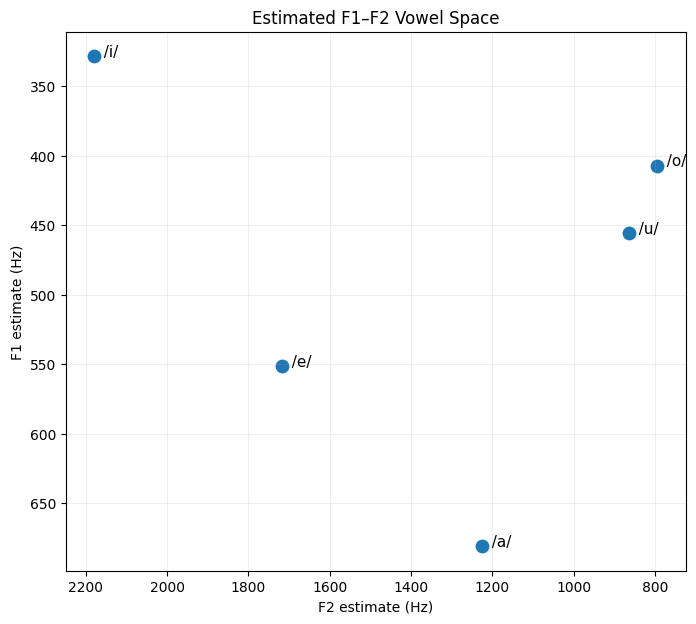

In [82]:
plt.figure(
  figsize=(8, 7)
)


plt.scatter(
  formant_df["F2_hz"],
  formant_df["F1_hz"],
  s=80,
)


for _, row in formant_df.iterrows():
  plt.text(
    row["F2_hz"],
    row["F1_hz"],
    f"  /{row['vowel']}/",
    fontsize=11,
  )


plt.xlabel(
  "F2 estimate (Hz)"
)

plt.ylabel(
  "F1 estimate (Hz)"
)

plt.title(
  "Estimated F1–F2 Vowel Space"
)


plt.gca().invert_xaxis()
plt.gca().invert_yaxis()


plt.grid(
  alpha=0.2
)


plt.show()

## 16. Common Spectral Envelope

The five vowels contain both shared and vowel-dependent spectral structure.

As a first DeVowel model, we construct a common spectral envelope representing spectral characteristics that remain relatively consistent across vowels.

For each vowel:

1. the two recorded takes are analyzed,
2. their spectral envelopes are averaged,
3. the five vowel-average envelopes are compared.

The pointwise median across vowels is used as an exploratory common envelope.

The median is preferred here because strongly vowel-specific peaks in one vowel have less influence on the common target than they would with a simple mean.

This common envelope is not assumed to be a pure glottal-source spectrum or a physiologically neutral vocal tract.

It is an empirical spectral reference for the first DeVowel experiment.

In [83]:
def build_common_vowel_envelope(
  wav_dir,
  vowels,
  takes=("01", "02"),
  min_freq=100,
  max_freq=5000,
  smoothing_sigma_hz=50,
):
  vowel_envelopes = {}

  reference_freqs = None


  for vowel in vowels:
    take_envelopes = []


    for take in takes:
      filename = (
        f"{vowel}_{take}.wav"
      )

      audio_path = (
        wav_dir / filename
      )


      wave_temp, sr_temp = sf.read(
        audio_path
      )


      freqs_temp, mag_db_temp = compute_spectrum(
        wave_temp,
        sr_temp,
      )


      envelope_temp = compute_spectral_envelope(
        freqs_temp,
        mag_db_temp,
        smoothing_sigma_hz=smoothing_sigma_hz,
      )


      mask = (
        (freqs_temp >= min_freq)
        & (freqs_temp <= max_freq)
      )


      freqs_roi = freqs_temp[
        mask
      ]

      envelope_roi = envelope_temp[
        mask
      ]


      if reference_freqs is None:
        reference_freqs = (
          freqs_roi
        )

      elif not np.allclose(
        freqs_roi,
        reference_freqs,
      ):
        raise ValueError(
          "Frequency axes are not identical."
        )


      take_envelopes.append(
        envelope_roi
      )


    take_envelopes = np.stack(
      take_envelopes,
      axis=0,
    )


    vowel_envelope = np.mean(
      take_envelopes,
      axis=0,
    )


    vowel_envelope = (
      vowel_envelope
      - np.max(vowel_envelope)
    )


    vowel_envelopes[
      vowel
    ] = vowel_envelope


  all_vowel_envelopes = np.stack(
    [
      vowel_envelopes[vowel]
      for vowel in vowels
    ],
    axis=0,
  )


  common_envelope = np.median(
    all_vowel_envelopes,
    axis=0,
  )


  common_envelope = (
    common_envelope
    - np.max(common_envelope)
  )


  return (
    reference_freqs,
    vowel_envelopes,
    common_envelope,
  )

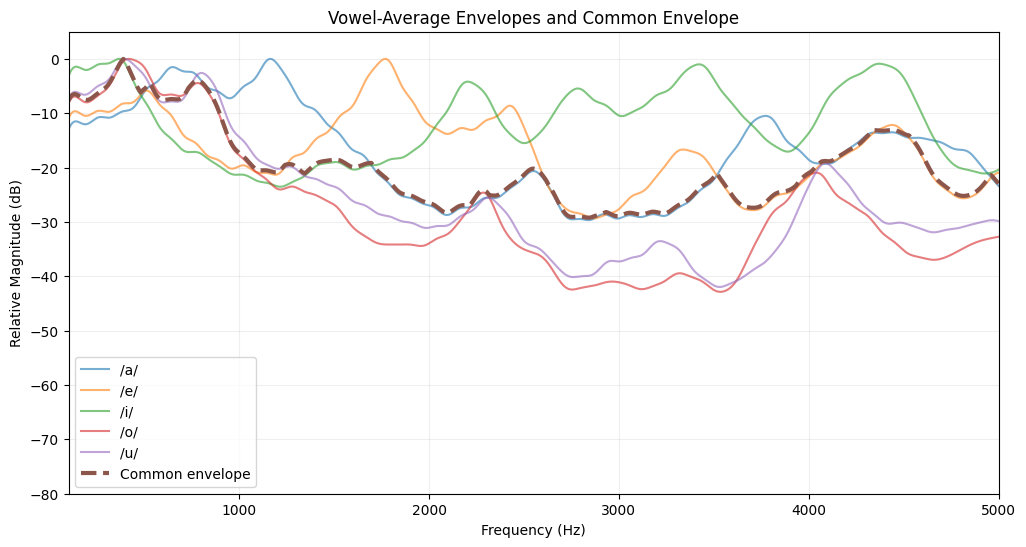

In [84]:
(
  common_freqs,
  vowel_envelopes,
  common_envelope,
) = build_common_vowel_envelope(
  wav_dir,
  vowels,
)


plt.figure(
  figsize=(12, 6)
)


for vowel in vowels:
  plt.plot(
    common_freqs,
    vowel_envelopes[vowel],
    alpha=0.6,
    label=f"/{vowel}/",
  )


plt.plot(
  common_freqs,
  common_envelope,
  linewidth=3,
  linestyle="--",
  label="Common envelope",
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Vowel-Average Envelopes and Common Envelope"
)

plt.xlim(
  100,
  5000,
)

plt.ylim(
  -80,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

## 17. Vowel-Specific Spectral Deviation

The difference between each vowel envelope and the common envelope is treated as an exploratory vowel-dependent spectral component.

For vowel v:

D_v(f) = E_v(f) - E_common(f)

Positive values indicate frequency regions emphasized relative to the common envelope.

Negative values indicate frequency regions attenuated relative to the common envelope.

If vowel identity is strongly represented by these deviations, reducing them should move different vowels toward a more similar spectral shape.

This is the first direct DeVowel hypothesis tested through resynthesis.

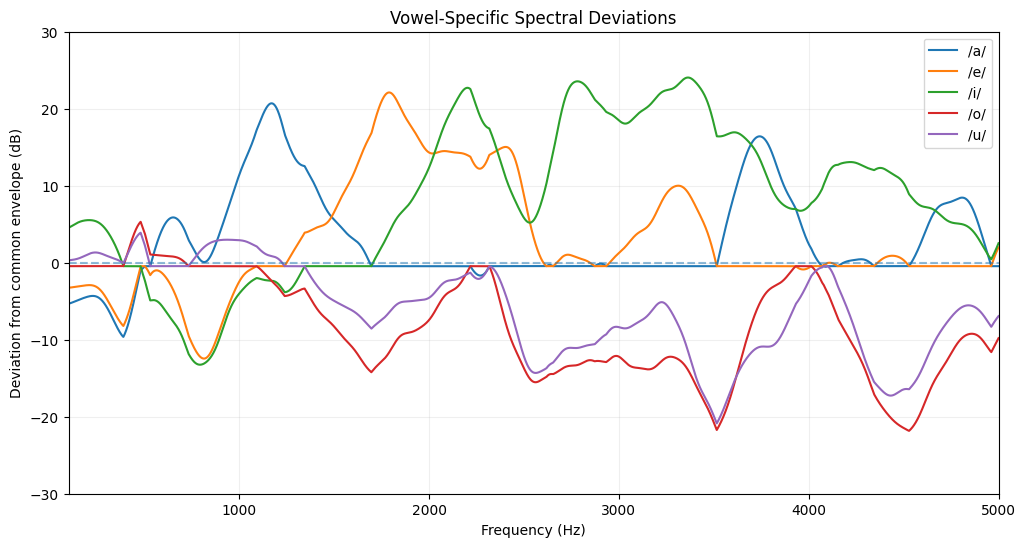

In [86]:
vowel_deviations = {}


plt.figure(
  figsize=(12, 6)
)


for vowel in vowels:
  deviation_db = (
    vowel_envelopes[vowel]
    - common_envelope
  )


  vowel_deviations[
    vowel
  ] = deviation_db


  plt.plot(
    common_freqs,
    deviation_db,
    label=f"/{vowel}/",
  )


plt.axhline(
  0,
  linestyle="--",
  alpha=0.5,
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Deviation from common envelope (dB)"
)

plt.title(
  "Vowel-Specific Spectral Deviations"
)

plt.xlim(
  100,
  5000,
)

plt.ylim(
  -30,
  30,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

## 18. DeVowel v0.1: Static Spectral Neutralization

The first DeVowel resynthesis experiment applies the inverse of the vowel-specific spectral deviation.

For each vowel:

correction(f) =
strength × [common_envelope(f) - vowel_envelope(f)]

The correction is applied to the STFT magnitude spectrum while preserving the original complex phase.

A correction-strength parameter allows gradual neutralization.

The gain is also limited to avoid excessively large boosts or cuts.

This is a static spectral-shaping experiment designed for sustained vowels.

It is not yet a general source-filter separation algorithm and is not intended for continuous speech.

In [87]:
def make_neutralization_curve(
  vowel_envelope,
  common_envelope,
  strength=0.5,
  max_correction_db=12,
):
  correction_db = (
    strength
    * (
      common_envelope
      - vowel_envelope
    )
  )


  correction_db = np.clip(
    correction_db,
    -max_correction_db,
    max_correction_db,
  )


  return correction_db

In [91]:
def make_neutralization_curve(
  vowel_envelope,
  common_envelope,
  strength=0.5,
  max_correction_db=12,
):
  correction_db = (
    strength
    * (
      common_envelope
      - vowel_envelope
    )
  )


  correction_db = np.clip(
    correction_db,
    -max_correction_db,
    max_correction_db,
  )


  return correction_db

In [93]:
def apply_static_spectral_correction(
  wave,
  sr,
  correction_freqs,
  correction_db,
  n_fft=4096,
  hop_length=512,
):
  spectrum_stft = librosa.stft(
    wave.astype(float),
    n_fft=n_fft,
    hop_length=hop_length,
    window="hann",
  )


  stft_freqs = librosa.fft_frequencies(
    sr=sr,
    n_fft=n_fft,
  )


  correction_interp_db = np.interp(
    stft_freqs,
    correction_freqs,
    correction_db,
    left=0.0,
    right=0.0,
  )


  gain = (
    10
    ** (
      correction_interp_db
      / 20
    )
  )


  corrected_stft = (
    spectrum_stft
    * gain[:, None]
  )


  corrected_wave = librosa.istft(
    corrected_stft,
    hop_length=hop_length,
    window="hann",
    length=len(wave),
  )


  peak = np.max(
    np.abs(corrected_wave)
  )


  if peak > 0.99:
    corrected_wave = (
      corrected_wave
      * (0.99 / peak)
    )


  return (
    corrected_wave,
    correction_interp_db,
  )

In [94]:
test_vowels = [
  "a",
  "i",
]


processed_dir = (
  project_dir
  / "audio"
  / "processed"
  / "v0_1"
)


processed_dir.mkdir(
  parents=True,
  exist_ok=True,
)


for vowel in test_vowels:
  filename = (
    f"{vowel}_01.wav"
  )


  audio_path = (
    wav_dir / filename
  )


  wave_temp, sr_temp = sf.read(
    audio_path
  )


  print()
  print(
    f"1. Original /{vowel}/"
  )

  display(
    Audio(
      wave_temp,
      rate=sr_temp,
    )
  )


  for strength in [
    0.5,
    1.0,
  ]:
    correction_db = make_neutralization_curve(
      vowel_envelopes[vowel],
      common_envelope,
      strength=strength,
      max_correction_db=12,
    )


    (
      neutralized_wave,
      correction_interp_db,
    ) = apply_static_spectral_correction(
      wave_temp,
      sr_temp,
      common_freqs,
      correction_db,
    )


    percentage = int(
      strength * 100
    )


    print(
      f"{percentage}% neutralized /{vowel}/"
    )


    display(
      Audio(
        neutralized_wave,
        rate=sr_temp,
      )
    )


    output_path = (
      processed_dir
      / (
        f"{vowel}_01_"
        f"neutral_{percentage}.wav"
      )
    )


    sf.write(
      output_path,
      neutralized_wave,
      sr_temp,
    )


    print(
      "Saved:",
      output_path.name
    )


1. Original /a/


50% neutralized /a/


Saved: a_01_neutral_50.wav
100% neutralized /a/


Saved: a_01_neutral_100.wav

1. Original /i/


50% neutralized /i/


Saved: i_01_neutral_50.wav
100% neutralized /i/


Saved: i_01_neutral_100.wav


## 21. Measuring the DeVowel Effect

Listening suggests that spectral neutralization reduces vowel identifiability while preserving a clearly human vocal quality.

Before increasing the correction strength, the processed signals are analyzed again.

The goal is to determine whether the spectral envelope of each processed vowel actually moves toward the common target envelope.

For each signal, we measure:

- envelope distance from the common target before processing,
- envelope distance after processing,
- correlation with the common target.

This separates perceptual observations from the actual spectral effect of the algorithm.

In [95]:
def measure_envelope_distance(
  wave,
  sr,
  common_freqs,
  common_envelope,
):
  freqs, mag_db = compute_spectrum(
    wave,
    sr,
  )


  envelope_db = compute_spectral_envelope(
    freqs,
    mag_db,
    smoothing_sigma_hz=50,
  )


  mask = (
    (freqs >= common_freqs[0])
    & (freqs <= common_freqs[-1])
  )


  freqs_roi = freqs[
    mask
  ]

  envelope_roi = envelope_db[
    mask
  ]


  target_interp = np.interp(
    freqs_roi,
    common_freqs,
    common_envelope,
  )


  mae_db = np.mean(
    np.abs(
      envelope_roi
      - target_interp
    )
  )


  correlation = np.corrcoef(
    envelope_roi,
    target_interp,
  )[0, 1]


  return (
    mae_db,
    correlation,
    freqs_roi,
    envelope_roi,
    target_interp,
  )

In [96]:
measurement_rows = []


for vowel in [
  "a",
  "i",
]:
  original_path = (
    wav_dir
    / f"{vowel}_01.wav"
  )


  wave_original, sr_original = sf.read(
    original_path
  )


  (
    mae_original,
    corr_original,
    _,
    _,
    _,
  ) = measure_envelope_distance(
    wave_original,
    sr_original,
    common_freqs,
    common_envelope,
  )


  measurement_rows.append({
    "vowel": vowel,
    "version": "original",
    "mae_to_common_db": mae_original,
    "corr_to_common": corr_original,
  })


  for percentage in [
    50,
    100,
  ]:
    processed_path = (
      processed_dir
      / (
        f"{vowel}_01_"
        f"neutral_{percentage}.wav"
      )
    )


    wave_processed, sr_processed = sf.read(
      processed_path
    )


    (
      mae_processed,
      corr_processed,
      _,
      _,
      _,
    ) = measure_envelope_distance(
      wave_processed,
      sr_processed,
      common_freqs,
      common_envelope,
    )


    measurement_rows.append({
      "vowel": vowel,
      "version": f"neutral_{percentage}",
      "mae_to_common_db": mae_processed,
      "corr_to_common": corr_processed,
    })


measurement_df = pd.DataFrame(
  measurement_rows
)


measurement_df = measurement_df.round({
  "mae_to_common_db": 2,
  "corr_to_common": 3,
})


display(
  measurement_df
)

,vowel,version,mae_to_common_db,corr_to_common
0,a,original,5.04,0.714
1,a,neutral_50,3.97,0.868
2,a,neutral_100,3.04,0.930
3,i,original,9.83,0.126
4,i,neutral_50,5.29,0.729
5,i,neutral_100,3.51,0.818


## 22. Steady-State Listening Comparison

The attack portion of the recordings contains strong temporal articulation cues.

To evaluate the effect of spectral neutralization independently from onset articulation, a short central segment is extracted from each original and processed recording.

This comparison focuses on the sustained steady-state portion of the vowel.

The attack-inclusive and steady-state listening tests answer different questions:

- full recording: how much total vowel articulation remains?
- steady-state segment: how much stationary spectral vowel identity remains?

In [97]:
def extract_center_segment(
  wave,
  sr,
  duration=1.5,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  return wave[
    start:end
  ]

In [98]:
stimulus_number = 1


for vowel in [
  "a",
  "i",
]:
  print()
  print(
    f"=== /{vowel}/ ==="
  )


  original_path = (
    wav_dir
    / f"{vowel}_01.wav"
  )


  wave_original, sr_original = sf.read(
    original_path
  )


  center_original = extract_center_segment(
    wave_original,
    sr_original,
  )


  print(
    f"{stimulus_number}. Original steady-state /{vowel}/"
  )

  display(
    Audio(
      center_original,
      rate=sr_original,
    )
  )

  stimulus_number += 1


  for percentage in [
    50,
    100,
  ]:
    processed_path = (
      processed_dir
      / (
        f"{vowel}_01_"
        f"neutral_{percentage}.wav"
      )
    )


    wave_processed, sr_processed = sf.read(
      processed_path
    )


    center_processed = extract_center_segment(
      wave_processed,
      sr_processed,
    )


    print(
      f"{stimulus_number}. "
      f"{percentage}% neutralized "
      f"steady-state /{vowel}/"
    )


    display(
      Audio(
        center_processed,
        rate=sr_processed,
      )
    )


    stimulus_number += 1


=== /a/ ===
1. Original steady-state /a/


2. 50% neutralized steady-state /a/


3. 100% neutralized steady-state /a/



=== /i/ ===
4. Original steady-state /i/


5. 50% neutralized steady-state /i/


6. 100% neutralized steady-state /i/
